# Patient Risk Classification - Classification Track Part A (Review 1)
**Course**: 23CSE301 Machine Learning - Capstone Project
**Project Title**: Healthcare Cost Prediction and Patient Risk Intelligence Using Machine Learning
**Dataset**: Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)
**Classification Target**: `is_high_risk`

---
### Academic Integrity Note
Per course guidelines, AI code scaffolding is used for code setup and structure. All analytical observations and domain interpretations are marked with **`TODO` placeholders** for student authoring.

Source/Citation: TODO — add source if external code was used.

## 1. Environment & Setup
Import required libraries and configure global random state (`random_state=42`).

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Setup complete. Random state set to 42.')

Setup complete. Random state set to 42.


## SECTION D — CLASSIFICATION PART A (3 MARKS)
Target Variable: `is_high_risk`

### Classification Feature Leakage Audit
**Decision**: `risk_score` is directly used to calculate `is_high_risk`. Including `risk_score` in predictor features would cause target leakage. Therefore, `risk_score` is explicitly excluded from input features.

TODO: Explain decision to exclude risk_score in detail.

In [2]:
# Stratified Train/Test Split (stratify=y, random_state=42)
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_classification()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nTrain Target Distribution (is_high_risk):')
print(y_train.value_counts(normalize=True))
print('\nTest Target Distribution (is_high_risk):')
print(y_test.value_counts(normalize=True))

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Train Target Distribution (is_high_risk):
is_high_risk
0    0.632188
1    0.367812
Name: proportion, dtype: float64

Test Target Distribution (is_high_risk):
is_high_risk
0    0.6322
1    0.3678
Name: proportion, dtype: float64


In [3]:
# Train All 5 Classification Algorithms
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results = model_training.train_classification(X_train, X_test, y_train, y_test, preprocessor)

Training KNN Classifier (on 8,000 row subsample for speed)...


Training Support Vector Machine (on 8,000 row subsample for speed)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Evaluating Baseline Classification Models:
Logistic Regression            | Acc: 0.9954 | Prec: 0.9973 | Rec: 0.9902 | F1: 0.9954 | AUC: 0.9998


K-Nearest Neighbors            | Acc: 0.8586 | Prec: 0.9133 | Rec: 0.6801 | F1: 0.8531 | AUC: 0.9399
Naive Bayes                    | Acc: 0.8355 | Prec: 0.7816 | Rec: 0.7671 | F1: 0.8352 | AUC: 0.9105
Decision Tree                  | Acc: 0.9977 | Prec: 0.9975 | Rec: 0.9962 | F1: 0.9977 | AUC: 0.9989


...

Best Logistic Regression Params: {'classifier__penalty': 'l2', 'classifier__C': 10.0}


Best Decision Tree Params: {'classifier__min_samples_split': 2, 'classifier__max_depth': None}
Fitting best Logistic Regression on full train set...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting best Decision Tree on full train set...


Best Classifier Model: Tuned Decision Tree saved to /Users/hemachandra/Documents/ML_capstone/models/best_classifier.joblib


### Preliminary Classification Comparison Table
Evaluated on Accuracy, Precision, Recall, Weighted F1-Score, and ROC-AUC:

In [4]:
df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Decision Tree,0.9988,0.998640,0.998097,0.998800,0.998653
1,Tuned Logistic Regression,0.9987,0.997827,0.998641,0.998700,0.999754
2,Decision Tree,0.9977,0.997550,0.996194,0.997700,0.998932
3,Logistic Regression,0.9954,0.997262,0.990212,0.995397,0.999757
4,Support Vector Machine,0.9656,0.967471,0.938010,0.965485,0.996215
5,K-Nearest Neighbors,0.8586,0.913290,0.680125,0.853142,0.939874
6,Naive Bayes,0.8355,0.781579,0.767129,0.835173,0.910456


### Confusion Matrices for All 5 Classification Algorithms

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


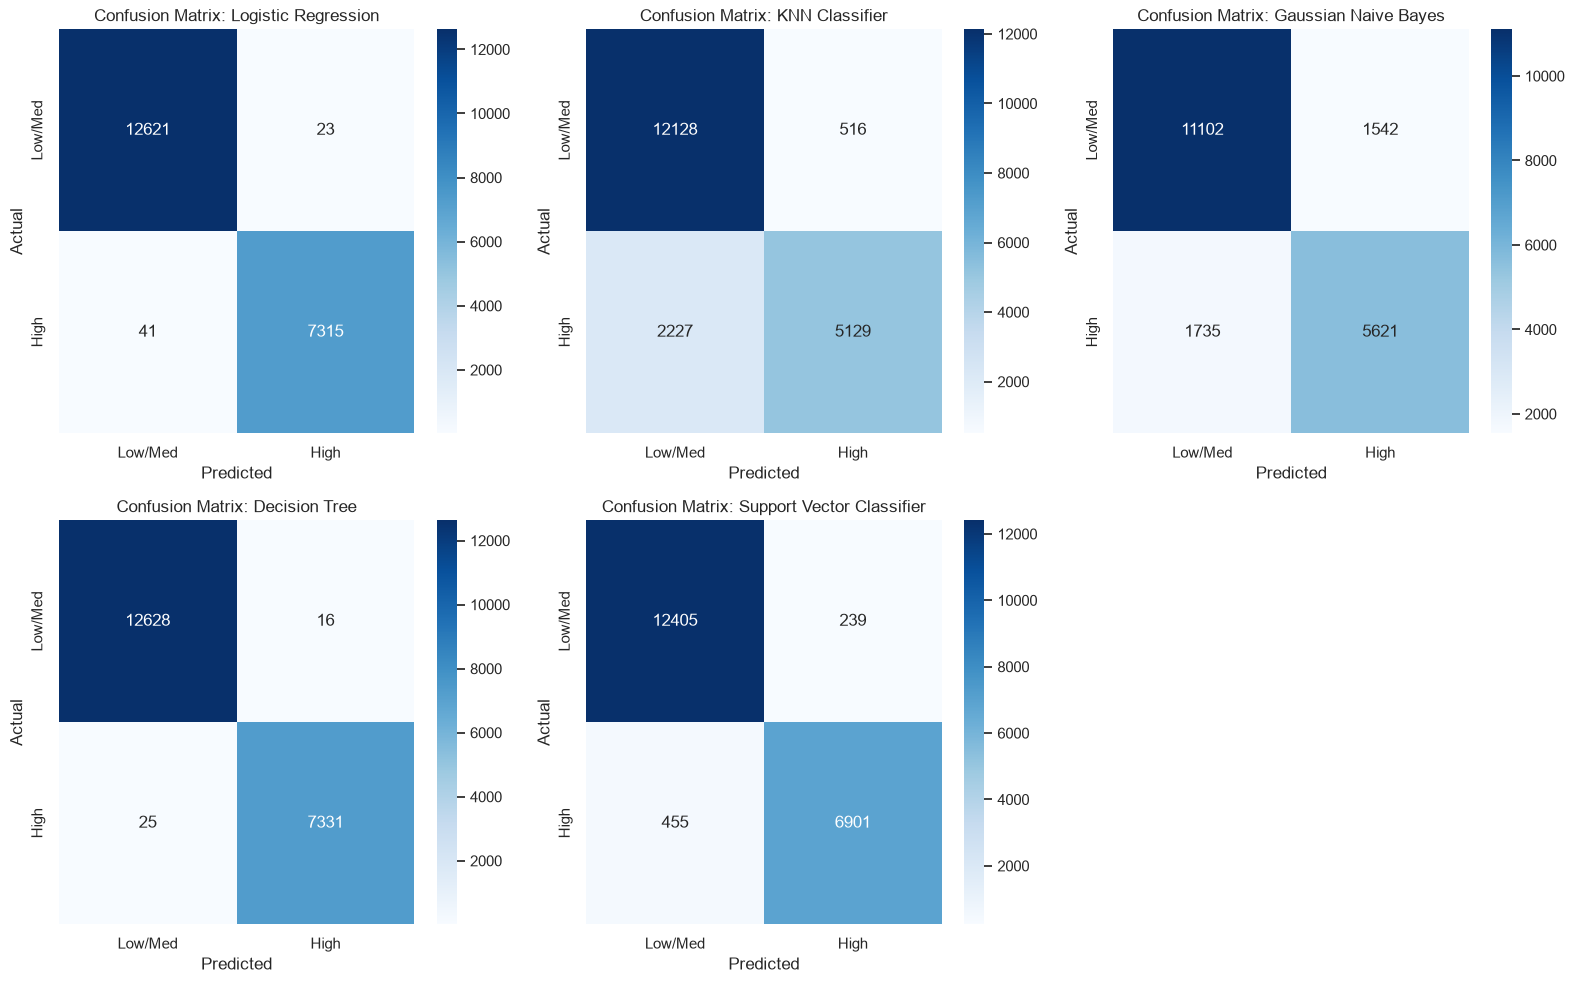

In [5]:
# Generate Confusion Matrix plots for all trained classification models
# Re-evaluate and plot for Logistic Regression, KNN, Naive Bayes, Decision Tree, and SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

subsample_idx = np.random.choice(len(X_train), size=min(8000, len(X_train)), replace=False)
X_train_sub = X_train.iloc[subsample_idx]
y_train_sub = y_train.iloc[subsample_idx]

models_dict = {
    'Logistic Regression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN Classifier': Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=7))]),
    'Gaussian Naive Bayes': Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'Decision Tree': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]),
    'Support Vector Classifier': Pipeline([('prep', preprocessor), ('clf', SVC(probability=True, random_state=42))])
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_dict.items()):
    if 'KNN' in name or 'Support' in name:
        model.fit(X_train_sub, y_train_sub)
    else:
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med', 'High'], yticklabels=['Low/Med', 'High'])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

axes[5].axis('off')
plt.tight_layout()
plt.show()

### Observation — Confusion Matrices
TODO: Write observation after inspecting this plot.

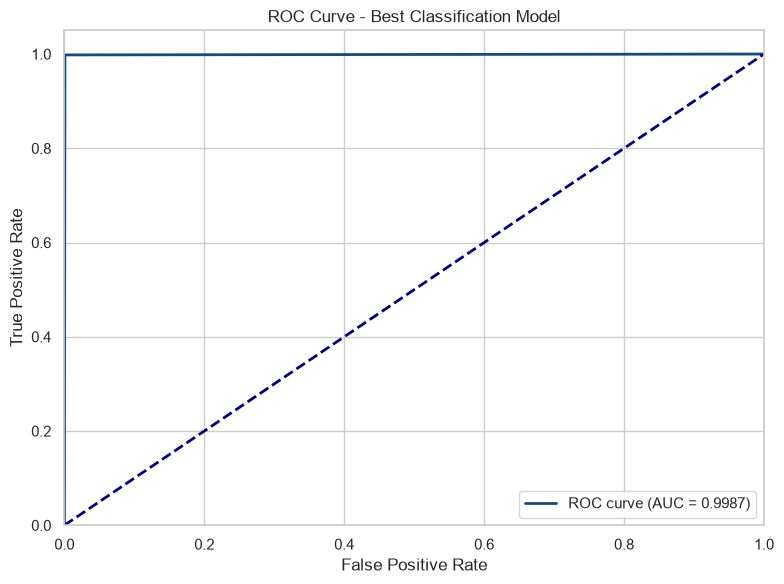

In [6]:
# ROC Curve for Best Classifier
best_clf = joblib.load(config.BEST_CLASSIFIER_PATH)
y_prob = best_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#0F4C81', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Classification Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Observation — ROC Curve
TODO: Write observation after inspecting this plot.

## FINAL REVIEW-1 OUTPUT & CHECKLIST

### Classification Review-1 Verification
| Criterion | Status |
| :--- | :---: |
| Target `is_high_risk` Defined | Verified |
| Risk Score Excluded (Leakage Prevention) | Verified |
| Stratified Train/Test Split (`random_state=42`) | Verified |
| All 5 Classification Algorithms Trained | Verified |
| Accuracy, Precision, Recall, Weighted F1, ROC-AUC Metrics | Verified |
| Confusion Matrices Plotted for All 5 Models | Verified |
| ROC Curve Plotted for Best Model | Verified |

### Human-Written TODO Checklist
- [ ] Write explanation for excluding risk_score from classification predictors
- [ ] Write observation for Confusion Matrices plot
- [ ] Write observation for ROC Curve plot